# Experiment 3 — class-imbalance robustness (PD)

Metric vs **minority-class proportion** (nested minority removal). One line per method, averaged over the folds of every included dataset (linear x), shown as raw points, **moving average**, and **relative** to each method's own best. Watch **AP_normalized** — the prevalence-corrected metric. Figures → `figures/experiment3/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, compute_time_bars, compute_time_boxplot,
    rank_heatmap, rank_boxplots, hpo_improvement_bars, runtime_performance_scatter,
    pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment3')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: c:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment3


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment3', task='pd', aggregated=False)
print(f'{df["method"].nunique()} methods, {df["dataset"].nunique()} datasets, '
      f'{df["sweep_value"].nunique()} sweep points')

2 methods, 6 datasets, 296 sweep points


## AUC (points, moving average, relative)

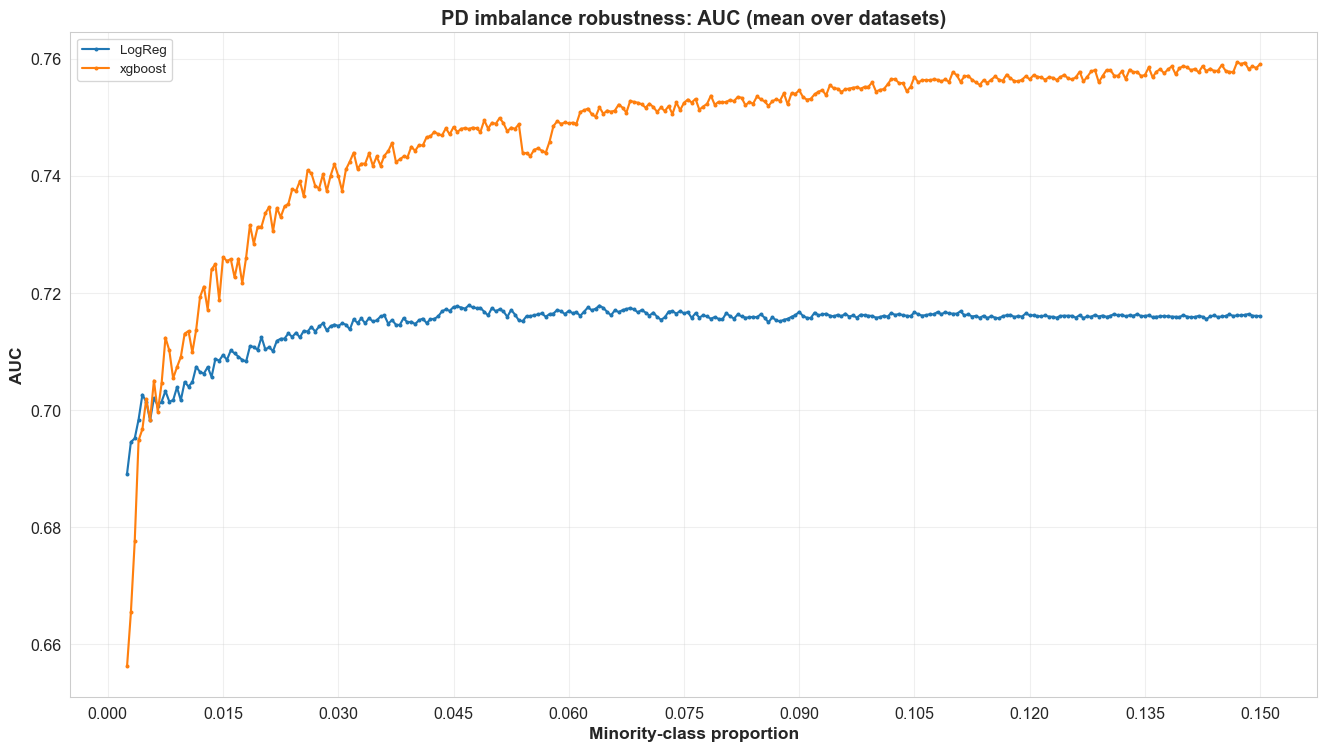

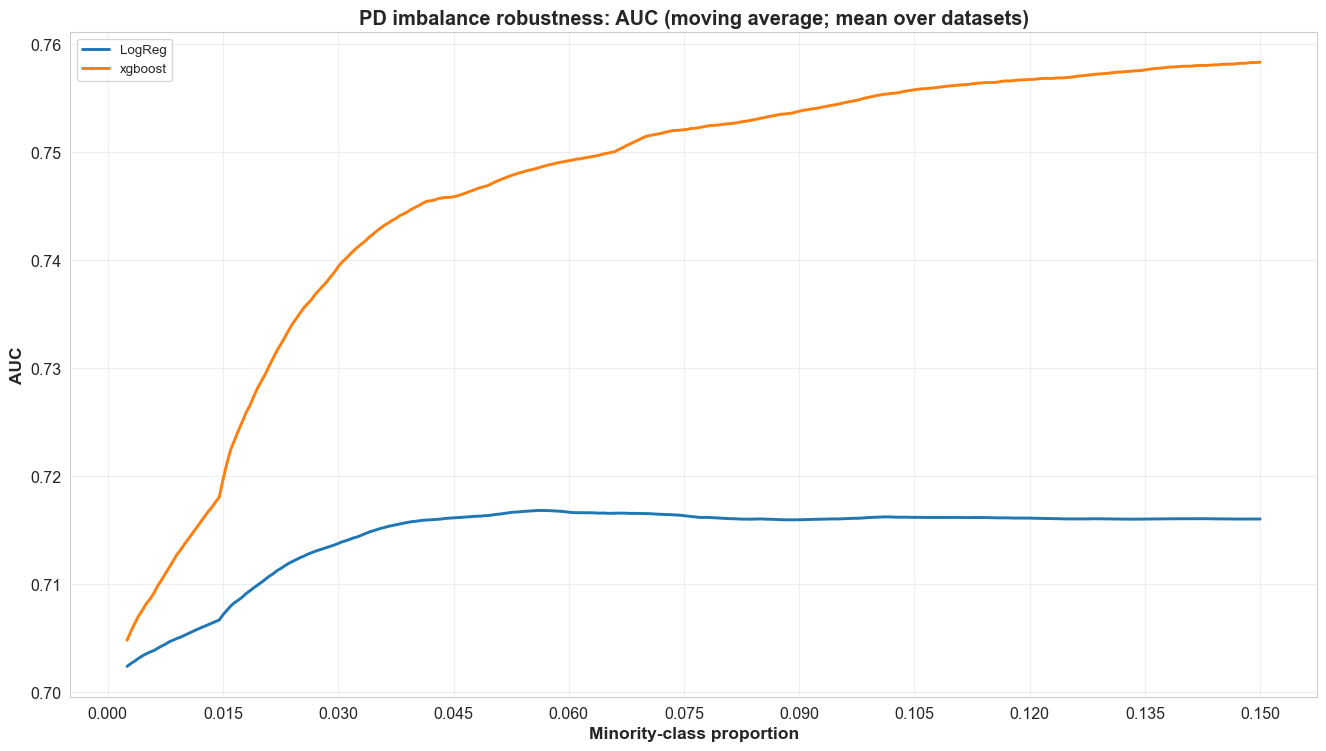

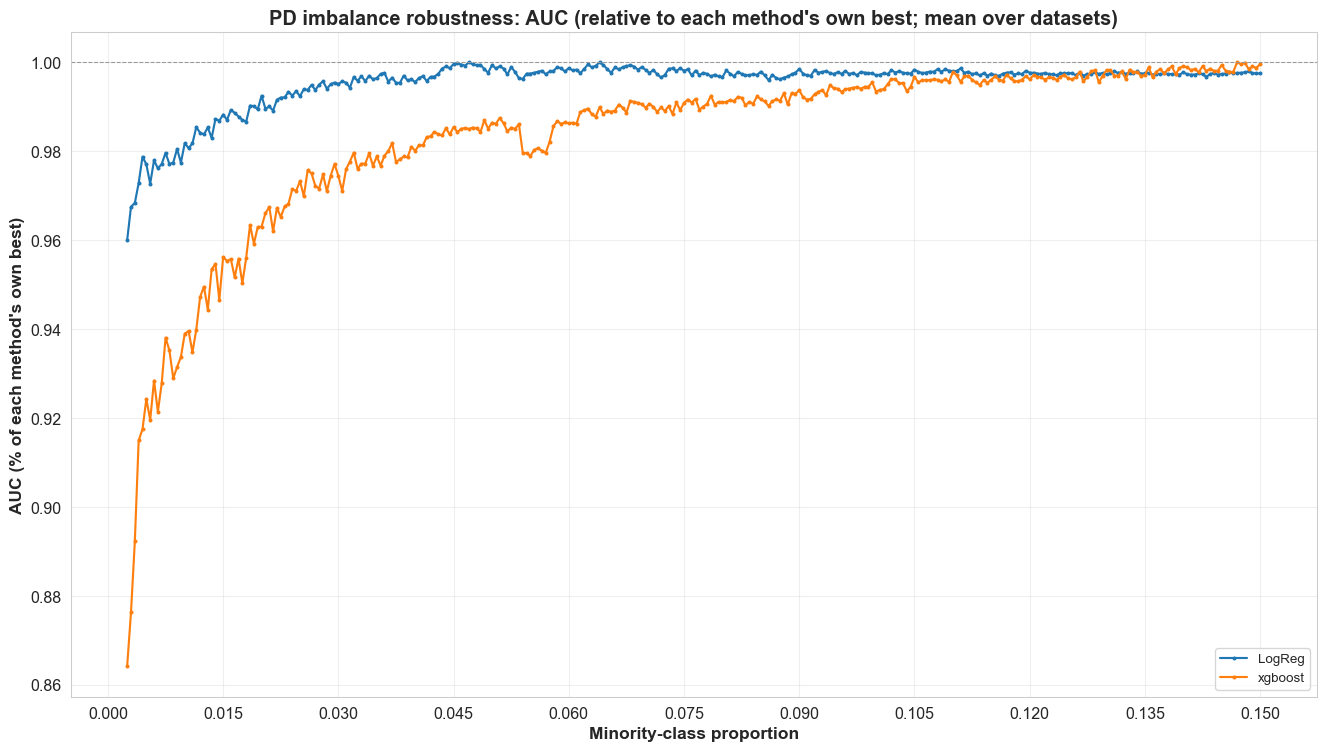

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_auc_relative.pdf')

In [3]:
imbalance_curve(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)
imbalance_curve(df, 'AUC', task_name='PD', smooth=True,   out_dir=FIGURES_DIR)
imbalance_curve(df, 'AUC', task_name='PD', relative=True, out_dir=FIGURES_DIR)

## AP_normalized (prevalence-corrected)

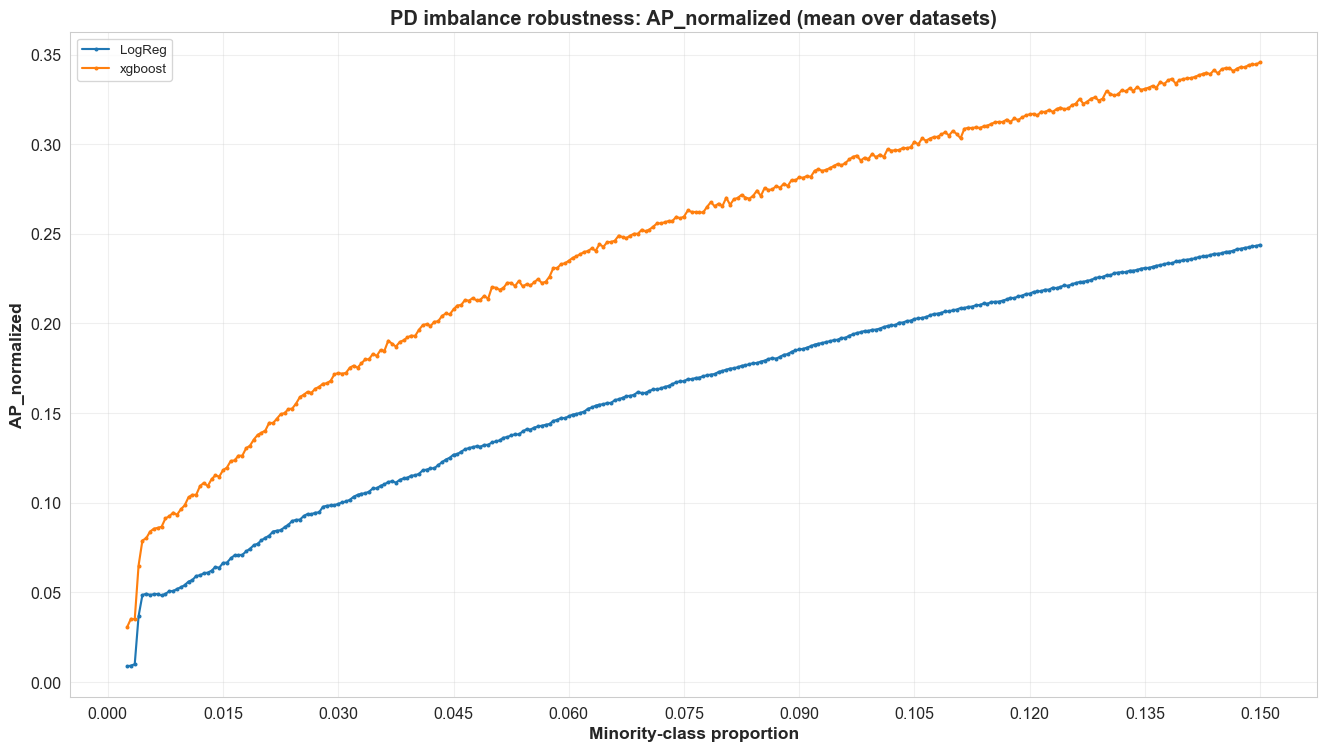

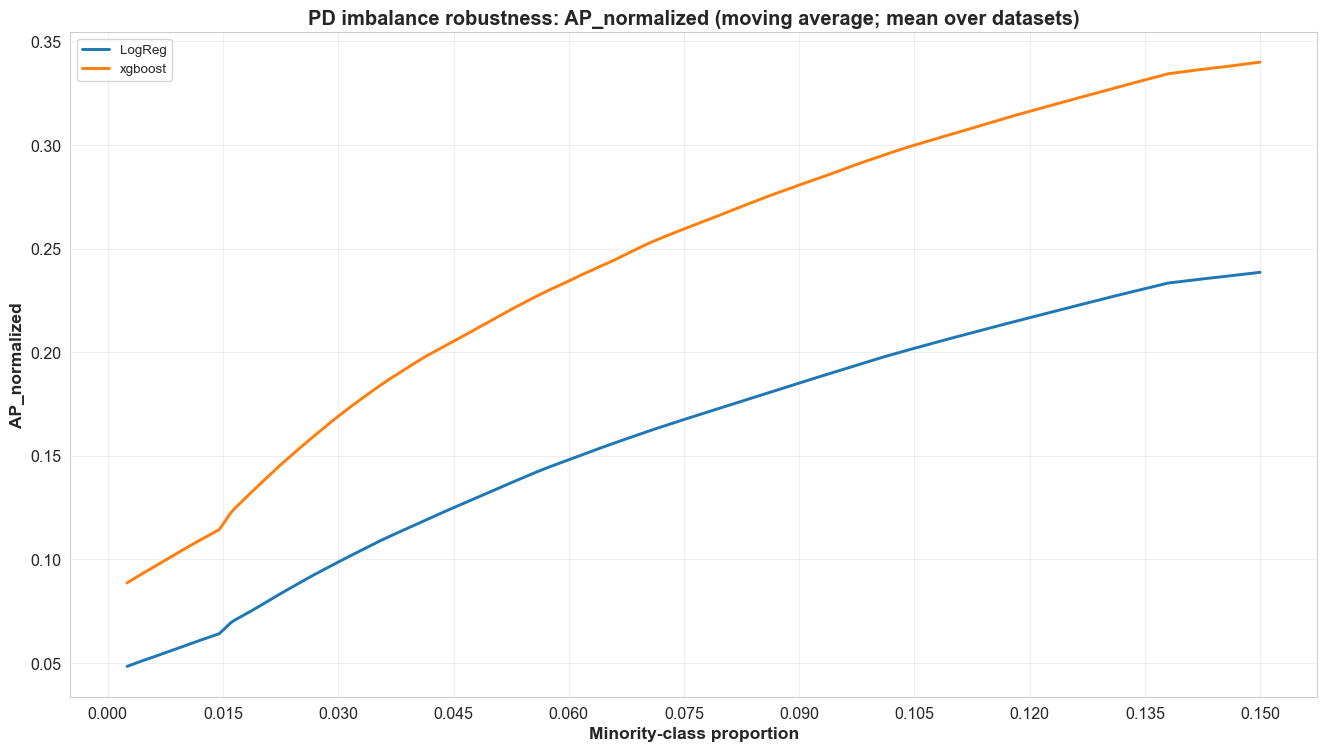

WindowsPath('c:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_ap_normalized_smooth.pdf')

In [4]:
imbalance_curve(df, 'AP_normalized', task_name='PD', out_dir=FIGURES_DIR)
imbalance_curve(df, 'AP_normalized', task_name='PD', smooth=True, out_dir=FIGURES_DIR)

## Degradation: AUC at the easiest minus the hardest setting

In [5]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.AUC'].mean().reset_index()
drop = {m: gg.sort_values('sweep_value').iloc[-1]['metric.AUC']
            - gg.sort_values('sweep_value').iloc[0]['metric.AUC']
        for m, gg in g.groupby('method')}
display(_pd.Series(drop, name='AUC(max minority) - AUC(min minority)').sort_values(ascending=False))

xgboost    0.102835
LogReg     0.026918
Name: AUC(max minority) - AUC(min minority), dtype: float64

## Summary (at the most balanced setting)

In [6]:
full = df[df['sweep_value'] == df['sweep_value'].max()]
pd_summary_text(full, task_name='Experiment 3 — PD @ max minority')

Experiment 3 — PD @ max minority — mean of every metric per method   (datasets: 6, methods: 2)
            AUC    Gini      KS  AP_normalized      F1  Accuracy  Balanced_Accuracy     MCC   Brier     ECE  LogLoss  Precision  Recall  Optimal_Threshold      AP  AP_baseline  AP_minus_baseline  Expected_Loss_Normalized  Optimal_Profit_Threshold  Optimal_Profit  H_Measure  time_s (median)
method                                                                                                                                                                                                                                                                                            
xgboost  0.7591  0.5181  0.4003         0.3457  0.4592    0.7631             0.6869  0.3450  0.1012  0.0065   0.3373     0.4107  0.5781             0.2102  0.4439         0.15             0.2939                    0.6380                    0.1810     -10855.1033     0.2744           0.3588
LogReg   0.7161  0.4321  0.3256 

'Experiment 3 — PD @ max minority — mean of every metric per method   (datasets: 6, methods: 2)\n==============================================================================================\n            AUC    Gini      KS  AP_normalized      F1  Accuracy  Balanced_Accuracy     MCC   Brier     ECE  LogLoss  Precision  Recall  Optimal_Threshold      AP  AP_baseline  AP_minus_baseline  Expected_Loss_Normalized  Optimal_Profit_Threshold  Optimal_Profit  H_Measure  time_s (median)\nmethod                                                                                                                                                                                                                                                                                            \nxgboost  0.7591  0.5181  0.4003         0.3457  0.4592    0.7631             0.6869  0.3450  0.1012  0.0065   0.3373     0.4107  0.5781             0.2102  0.4439         0.15             0.2939                    0.6380   